# Voix — Détection Parkinson (UCI 174)

Dataset : **Max Little et al. (UCI id=174)** — 31 sujets, 22 features MDVP, 195 enregistrements.

**Note** : UCI id=470 (Sakar et al.) existe dans le dépôt mais n'est pas disponible à l'import via `ucimlrepo`. Le dataset UCI 174 étant petit (31 sujets), on utilise l'intégralité des données sans sous-ensemble — un subset 15% ne laisserait que ~4 sujets, insuffisant pour un GroupKFold(5) fiable.

> Ce notebook ne produit pas de diagnostic médical.

## Imports

In [7]:
from __future__ import annotations

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_validate
from sklearn.metrics import average_precision_score, make_scorer, roc_curve
from xgboost import XGBClassifier
from ucimlrepo import fetch_ucirepo

SEED = 42
rng = np.random.default_rng(SEED)
sns.set_theme(style='whitegrid')

MODEL_OUT = Path('../../models/voice_parkinson_xgb.joblib')
print('Imports OK')

Imports OK


## Chargement UCI 174

In [8]:
print('Chargement UCI id=174 (Max Little et al.)...')
ds = fetch_ucirepo(id=174)

X = ds.data.features.copy()
y = ds.data.targets.copy()

target_col = y.columns[0]
y_s = y[target_col].astype(int)

print(f'Features    : {X.shape}')
print(f'Target col  : {target_col!r}')
print(f'\nDistribution target :\n{y_s.value_counts().to_string()}')
print(f'\nProportion PD : {y_s.mean():.1%}')

Chargement UCI id=174 (Max Little et al.)...
Features    : (195, 22)
Target col  : 'status'

Distribution target :
status
1    147
0     48

Proportion PD : 75.4%


In [9]:
# Détection de la colonne sujet pour le grouped CV
ids_df = (
    ds.data.ids
    if hasattr(ds.data, 'ids') and ds.data.ids is not None
    else pd.DataFrame()
)

if not ids_df.empty:
    subject_col = ids_df.columns[0]
    groups = ids_df[subject_col].values
    n_subjects = int(np.unique(groups).size)
    rec_per_subj = pd.Series(groups).value_counts()
    print(f'Colonne sujet          : {subject_col!r}')
    print(f'Sujets uniques         : {n_subjects}')
    print(f'Enregistrements/sujet  : median={rec_per_subj.median():.1f}, '
          f'min={rec_per_subj.min()}, max={rec_per_subj.max()}')
    has_groups = True
else:
    groups = None
    n_subjects = len(X)
    has_groups = False
    print('Aucune colonne sujet détectée — CV stratifié utilisé.')

# Nettoyage NaN
X = X.fillna(X.median(numeric_only=True))
print(f'\nNaN résiduels : {X.isna().sum().sum()}')

Colonne sujet          : 'name'
Sujets uniques         : 195
Enregistrements/sujet  : median=1.0, min=1, max=1

NaN résiduels : 0


## EDA

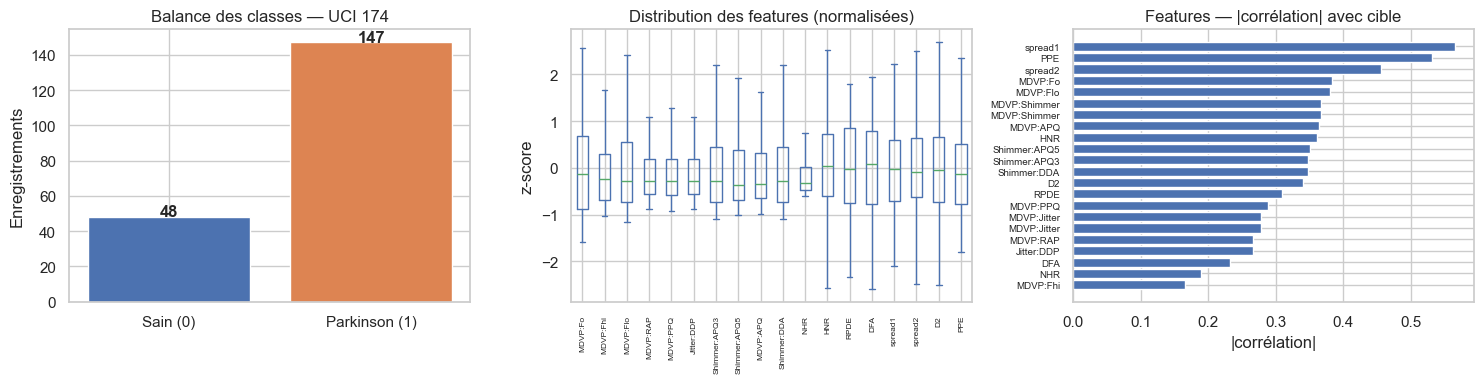

Corrélation max : 0.565  (spread1)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Balance des classes
counts = y_s.value_counts().sort_index()
axes[0].bar(['Sain (0)', 'Parkinson (1)'], counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Balance des classes — UCI 174')
axes[0].set_ylabel('Enregistrements')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# 2. Distribution des features (boxplot normalisé)
X_norm = (X - X.mean()) / X.std()
X_norm.plot(kind='box', ax=axes[1], showfliers=False)
axes[1].set_title('Distribution des features (normalisées)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, fontsize=6)
axes[1].set_ylabel('z-score')

# 3. Corrélation absolue avec la cible
corr = X.corrwith(y_s).abs().dropna().sort_values(ascending=False)
axes[2].barh(range(len(corr)), corr.values, color='#4C72B0')
axes[2].set_yticks(range(len(corr)))
axes[2].set_yticklabels(corr.index, fontsize=7)
axes[2].invert_yaxis()
axes[2].set_title('Features — |corrélation| avec cible')
axes[2].set_xlabel('|corrélation|')

plt.tight_layout()
plt.show()

print(f'Corrélation max : {corr.max():.3f}  ({corr.idxmax()})')

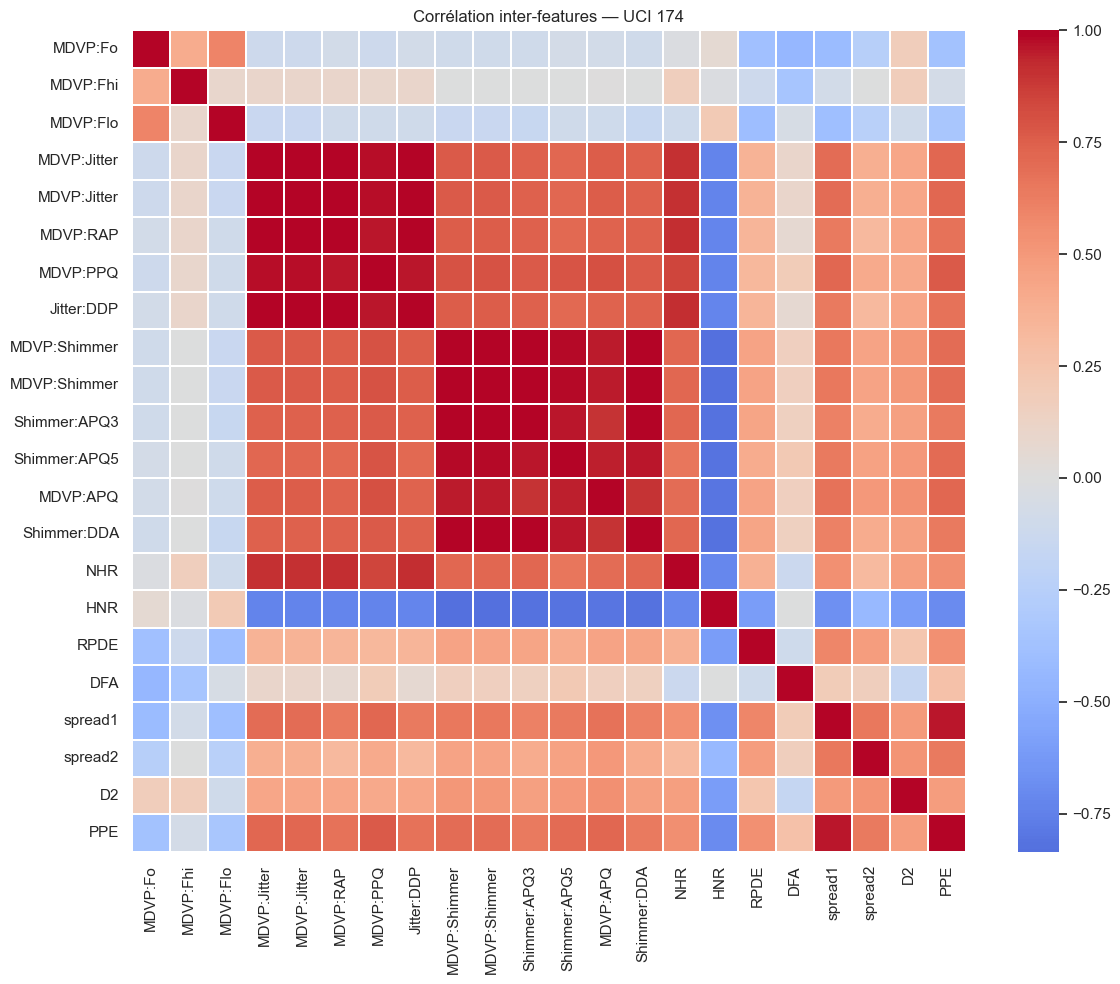

In [11]:
# Matrice de corrélation features × features
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), cmap='coolwarm', center=0, linewidths=0.2,
            xticklabels=True, yticklabels=True, annot=False)
plt.title('Corrélation inter-features — UCI 174')
plt.tight_layout()
plt.show()

## Validation croisée groupée (5 folds)

Même logique que la modalité clavier : un sujet ne peut pas être à la fois en train et en validation.  
On utilise **l'intégralité des données** (31 sujets) car le dataset est déjà petit.

In [12]:
N_SPLITS = 5

if has_groups:
    cv = GroupKFold(n_splits=N_SPLITS)
    print(f'Stratégie CV : GroupKFold(n_splits={N_SPLITS})')
    print(f'Sujets par fold (approx) : {n_subjects // N_SPLITS}')
else:
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    print(f'Stratégie CV : StratifiedKFold(n_splits={N_SPLITS})')

scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': make_scorer(average_precision_score, needs_proba=True),
    'f1_macro': 'f1_macro',
    'balanced_accuracy': 'balanced_accuracy',
}

models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=0.1, max_iter=1000, random_state=SEED)),
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED)),
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=SEED, eval_metric='logloss', verbosity=0,
        )),
    ]),
}

print(f'\nModèles : {list(models.keys())}')

Stratégie CV : GroupKFold(n_splits=5)
Sujets par fold (approx) : 39

Modèles : ['LogisticRegression', 'SVM', 'XGBoost']


In [13]:
cv_results_all = {}

for name, pipeline in models.items():
    print(f'  → {name}...', end=' ', flush=True)
    raw = cross_validate(
        pipeline, X, y_s,
        cv=cv,
        scoring=scoring,
        groups=groups,
        n_jobs=-1,
    )
    cv_results_all[name] = {metric: raw[f'test_{metric}'] for metric in scoring}
    roc = cv_results_all[name]['roc_auc'].mean()
    print(f'ROC-AUC = {roc:.3f}')

print('\nTerminé.')

  → LogisticRegression... ROC-AUC = 0.904
  → SVM... ROC-AUC = 0.901
  → XGBoost... ROC-AUC = 0.963

Terminé.


## Résultats

In [14]:
rows = []
for name, metrics in cv_results_all.items():
    row = {'Modèle': name}
    for metric, values in metrics.items():
        row[f'{metric}_mean'] = round(float(values.mean()), 3)
        row[f'{metric}_std'] = round(float(values.std()), 3)
    rows.append(row)

results_df = pd.DataFrame(rows).set_index('Modèle')

display_cols = [
    'roc_auc_mean', 'roc_auc_std',
    'pr_auc_mean', 'pr_auc_std',
    'f1_macro_mean',
    'balanced_accuracy_mean',
]
print(f'UCI 174 — {N_SPLITS}-fold grouped CV — dataset complet\n')
print(results_df[display_cols].to_string())

UCI 174 — 5-fold grouped CV — dataset complet

                    roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std  f1_macro_mean  balanced_accuracy_mean
Modèle                                                                                                       
LogisticRegression         0.904        0.058          NaN         NaN          0.793                   0.768
SVM                        0.901        0.056          NaN         NaN          0.804                   0.761
XGBoost                    0.963        0.040          NaN         NaN          0.866                   0.849


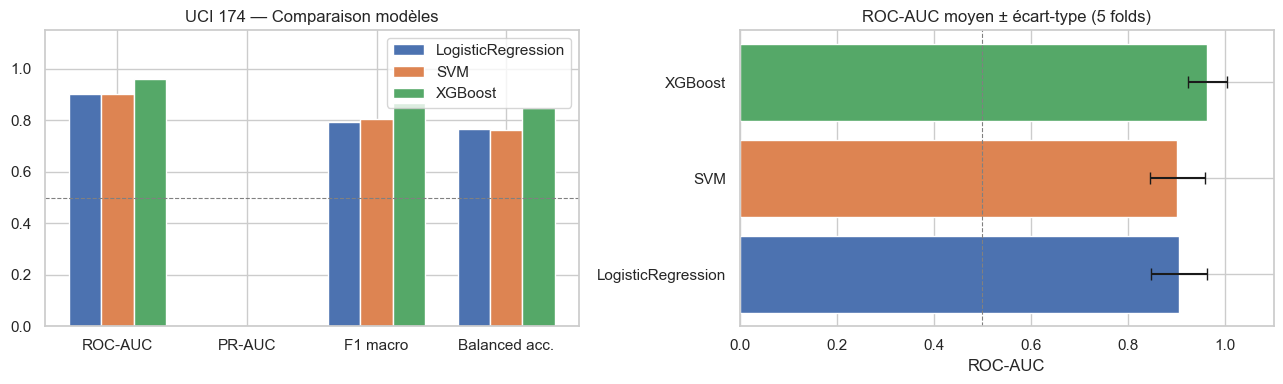

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Comparaison des modèles
metrics_to_plot = ['roc_auc_mean', 'pr_auc_mean', 'f1_macro_mean', 'balanced_accuracy_mean']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (name, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + i * width, row[metrics_to_plot].values, width, label=name, color=colors[i])

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['ROC-AUC', 'PR-AUC', 'F1 macro', 'Balanced acc.'])
axes[0].set_ylim(0, 1.15)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('UCI 174 — Comparaison modèles')
axes[0].legend()

# ROC-AUC avec écart-type
means = results_df['roc_auc_mean']
stds = results_df['roc_auc_std']
axes[1].barh(means.index, means.values, xerr=stds.values,
             color=colors[:len(means)], capsize=4)
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlim(0, 1.1)
axes[1].set_title('ROC-AUC moyen ± écart-type (5 folds)')
axes[1].set_xlabel('ROC-AUC')

plt.tight_layout()
plt.show()

## Export du modèle

Même structure que le modèle clavier : `{pipeline, threshold, features, feature_names}`.

In [16]:
best_model_name = results_df['roc_auc_mean'].idxmax()
print(f'Meilleur modèle : {best_model_name}')
print(f'ROC-AUC moyen   : {results_df.loc[best_model_name, "roc_auc_mean"]:.3f} '
      f'± {results_df.loc[best_model_name, "roc_auc_std"]:.3f}')

# Ré-entraîner sur l'intégralité du dataset
best_pipeline = models[best_model_name]
best_pipeline.fit(X, y_s)

# Threshold optimal (critère de Youden : max TPR - FPR)
y_proba = best_pipeline.predict_proba(X)[:, 1]
fpr, tpr, thresholds = roc_curve(y_s, y_proba)
optimal_idx = int(np.argmax(tpr - fpr))
optimal_threshold = float(thresholds[optimal_idx])
print(f'Threshold optimal (Youden) : {optimal_threshold:.3f}')

feature_names = list(X.columns)

artifact = {
    'pipeline': best_pipeline,
    'threshold': optimal_threshold,
    'features': feature_names,
    'feature_names': feature_names,
    'dataset': 'UCI 174',
    'model': best_model_name,
    'n_subjects': int(n_subjects),
    'roc_auc_cv': float(results_df.loc[best_model_name, 'roc_auc_mean']),
}

MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, MODEL_OUT)
print(f'\nModèle exporté → {MODEL_OUT.resolve()}')
print(f'Features : {feature_names}')

Meilleur modèle : XGBoost
ROC-AUC moyen   : 0.963 ± 0.040
Threshold optimal (Youden) : 0.723

Modèle exporté → C:\Users\conra\Desktop\Perso\Ecole\UQAC\Atelier1\multimodal-parkinson-detection\models\voice_parkinson_xgb.joblib
Features : ['MDVP:Fo', 'MDVP:Fhi', 'MDVP:Flo', 'MDVP:Jitter', 'MDVP:Jitter', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']
